In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import seaborn as sns
import geopandas as gpd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import pickle
import joblib
import osmnx as ox
import networkx as nx
from datetime import datetime, timedelta


pd.options.mode.copy_on_write = True

# Achar Sample

In [2]:
df = pd.read_csv('../dados/curitiba_foursquare_purpose.csv')
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE
0,59907035,2014-02-12 13:54:32-02:00,Sandwiches,GUAÍRA,-25.469176,-49.282521,13,2,Wednesday,LEISURE
1,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
2,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
3,43112636,2014-04-23 23:45:41-03:00,Soccer,ÁGUA VERDE,-25.462514,-49.277967,23,2,Wednesday,LEISURE
4,37412621,2014-04-23 23:47:00-03:00,Home,CENTRO,-25.438156,-49.279074,23,2,Wednesday,HOME
...,...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18 18:38:07-03:00,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144,18,2,Wednesday,LEISURE
53209,12974483,2014-06-18 18:41:13-03:00,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371,18,2,Wednesday,OTHER
53210,17082636,2014-06-18 18:42:24-03:00,Mall,CENTRO,-25.440988,-49.277436,18,2,Wednesday,PURCHASE
53211,17082636,2014-06-18 18:42:35-03:00,Beer-Store,CENTRO,-25.440845,-49.277071,18,2,Wednesday,PURCHASE


In [21]:
# Convert DATE to datetime and extract date only
df['DATE'] = pd.to_datetime(df['DATE'], utc=True)
df['DATE_ONLY'] = df['DATE'].dt.date

# Count check-ins per user per day
daily_checkins = df.groupby(['ID_USER', 'DATE_ONLY']).size().reset_index(name='checkins_count')

# Find users with exactly 5 check-ins on the same day
users_with_5_checkins = daily_checkins[daily_checkins['checkins_count'] == 5]

print("Users with exactly 5 check-ins on the same day:")
print(f"Found {len(users_with_5_checkins)} users")

# Analyze purpose diversity for each user-day combination with 5 check-ins
diversity_analysis = []

for _, row in users_with_5_checkins.iterrows():
    user_id = row['ID_USER']
    date = row['DATE_ONLY']
    
    user_checkins = df[(df['ID_USER'] == user_id) & (df['DATE_ONLY'] == date)]
    
    # Count unique purposes
    unique_purposes = user_checkins['PURPOSE'].nunique()
    purpose_list = user_checkins['PURPOSE'].unique().tolist()
    
    diversity_analysis.append({
        'ID_USER': user_id,
        'DATE_ONLY': date,
        'unique_purposes': unique_purposes,
        'purposes': purpose_list,
        'checkins_data': user_checkins[['HOUR', 'Bairro', 'CATEGORIA_MAE', 'PURPOSE']].sort_values('HOUR')
    })

# Sort by diversity (number of unique purposes)
diversity_df = pd.DataFrame([{
    'ID_USER': item['ID_USER'],
    'DATE_ONLY': item['DATE_ONLY'],
    'unique_purposes': item['unique_purposes'],
    'purposes': ', '.join(item['purposes'])
} for item in diversity_analysis])

diversity_df = diversity_df.sort_values('unique_purposes', ascending=False)

print("\nUsers with 5 check-ins ranked by purpose diversity:")
print(diversity_df)

# Show the most diverse user's check-ins
if len(diversity_analysis) > 0:
    most_diverse = max(diversity_analysis, key=lambda x: x['unique_purposes'])
    
    print(f"\nMost diverse user: {most_diverse['ID_USER']} on {most_diverse['DATE_ONLY']}")
    print(f"Number of unique purposes: {most_diverse['unique_purposes']}")
    print(f"Purposes: {', '.join(most_diverse['purposes'])}")
    print("\nDetailed check-ins:")
    print(most_diverse['checkins_data'])
    
    # Save this as test data
    test_data = most_diverse['checkins_data'].copy()
    print(f"\nSaving test data for user {most_diverse['ID_USER']}...")
    
# Show top 3 most diverse users
print(f"\nTop 3 most diverse users:")
for i, item in enumerate(sorted(diversity_analysis, key=lambda x: x['unique_purposes'], reverse=True)[:3]):
    print(f"\n{i+1}. User {item['ID_USER']} on {item['DATE_ONLY']}:")
    print(f"   Unique purposes: {item['unique_purposes']}")
    print(f"   Purposes: {', '.join(item['purposes'])}")
    print("   Check-ins:")
    print(item['checkins_data'].to_string(index=False))
    print("-" * 60)

Users with exactly 5 check-ins on the same day:
Found 474 users

Users with 5 check-ins ranked by purpose diversity:
      ID_USER   DATE_ONLY  unique_purposes  \
310  53308444  2014-05-19                5   
37    7461856  2014-05-14                5   
462  84249997  2014-05-28                5   
306  53308444  2014-05-12                5   
448  82458643  2014-05-16                4   
..        ...         ...              ...   
96   12785992  2014-05-17                1   
150  23290602  2014-05-18                1   
144  20611806  2014-06-09                1   
433  81423575  2014-04-28                1   
3     3439053  2014-06-07                1   

                                 purposes  
310  PURCHASE, OTHER, WORK, LEISURE, HOME  
37   WORK, LEISURE, HOME, PURCHASE, OTHER  
462  PURCHASE, OTHER, HOME, LEISURE, WORK  
306  LEISURE, PURCHASE, HOME, WORK, OTHER  
448         PURCHASE, HOME, LEISURE, WORK  
..                                    ...  
96                    

# Gerar Trajetória

In [23]:
sample_df = df[(df["ID_USER"] == 53308444) & (df["DATE_ONLY"] == pd.to_datetime("2014-05-19").date())]
sample_df = sample_df.sort_values("HOUR")
sample_df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE,DATE_ONLY
30747,53308444,2014-05-19 10:51:41+00:00,High-School,SANTA CÂNDIDA,-25.374541,-49.224360,7,0,Monday,WORK,2014-05-19
31278,53308444,2014-05-19 17:06:07+00:00,Building,CENTRO CÍVICO,-25.418538,-49.268290,14,0,Monday,OTHER,2014-05-19
31456,53308444,2014-05-19 20:08:24+00:00,Bank,CENTRO CÍVICO,-25.420326,-49.269062,17,0,Monday,PURCHASE,2014-05-19
31610,53308444,2014-05-19 21:53:25+00:00,Sandwiches,ALTO DA GLÓRIA,-25.417994,-49.262153,18,0,Monday,LEISURE,2014-05-19
31746,53308444,2014-05-19 22:56:12+00:00,Residential,BACACHERI,-25.392531,-49.229802,19,0,Monday,HOME,2014-05-19


In [36]:
# Extract coordinates from the sample data
locations = []
for _, row in sample_df.iterrows():
    locations.append((row['LAT'], row['LONG']))

print(f"Number of check-ins: {len(locations)}")
print("Check-in locations (lat, lon):")
for i, loc in enumerate(locations):
    print(f"{i+1}. {loc} - {sample_df.iloc[i]['CATEGORIA_MAE']} at hour {sample_df.iloc[i]['HOUR']}")

# Get the center point for downloading the street network
center_lat = sample_df['LAT'].mean()
center_lon = sample_df['LONG'].mean()
center_coords = (center_lat, center_lon)

print(f"\nCenter coordinates: {center_coords}")

# Download the street network for Curitiba area
# Using a larger distance to cover all check-in points
G = ox.graph_from_point(center_coords, dist=10000, network_type='drive')

print(f"Downloaded street network with {len(G.nodes)} nodes and {len(G.edges)} edges")

# Find the nearest network nodes for each check-in location
nodes = ox.nearest_nodes(G, [loc[1] for loc in locations], [loc[0] for loc in locations])

print(f"Found nearest network nodes: {nodes}")

# Calculate the full trajectory by connecting all check-ins in chronological order
full_route = []
total_distance = 0

for i in range(len(nodes) - 1):
    try:
        route_segment = nx.shortest_path(G, source=nodes[i], target=nodes[i+1], weight='length')
        
        # Calculate segment distance
        segment_distance = nx.shortest_path_length(G, source=nodes[i], target=nodes[i+1], weight='length')
        total_distance += segment_distance
        
        print(f"Segment {i+1}: {len(route_segment)} nodes, {segment_distance:.0f} meters")
        
        # Add to full route (avoid duplicating nodes between segments)
        if i == 0:
            full_route.extend(route_segment)
        else:
            full_route.extend(route_segment[1:])  # Skip first node to avoid duplication
            
    except nx.NetworkXNoPath:
        print(f"Warning: No path found between check-ins {i+1} and {i+2}")

print(f"\nTotal trajectory: {len(full_route)} nodes, {total_distance:.0f} meters total distance")

Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.374540548, -49.2243601686) - High-School at hour 7
2. (-25.4185378571, -49.2682900524) - Building at hour 14
3. (-25.4203256745, -49.2690621799) - Bank at hour 17
4. (-25.4179939823, -49.2621529964) - Sandwiches at hour 18
5. (-25.392531, -49.229802) - Residential at hour 19

Center coordinates: (np.float64(-25.404785812380002), np.float64(-49.25073347946))
Downloaded street network with 30096 nodes and 77290 edges
Found nearest network nodes: [5837368337 5265917367 3610984066  865726774 1408449258]
Segment 1: 63 nodes, 7223 meters
Segment 2: 11 nodes, 1434 meters
Segment 3: 8 nodes, 877 meters
Segment 4: 43 nodes, 4672 meters

Total trajectory: 122 nodes, 14206 meters total distance


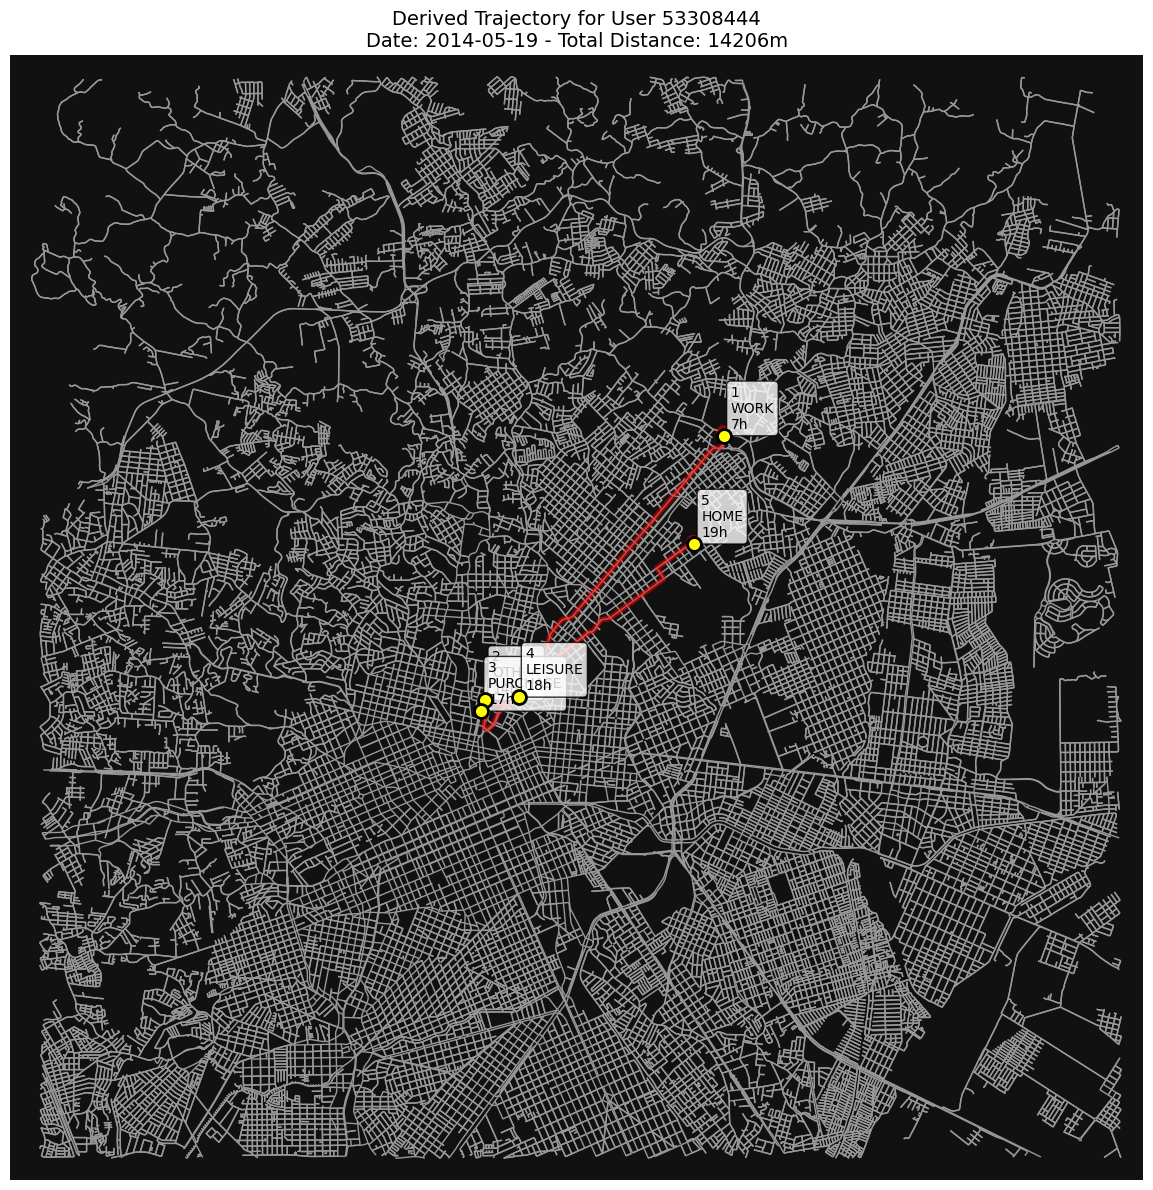

In [37]:
fig, ax = ox.plot_graph_route(
    G,
    full_route,
    route_color='red',
    route_linewidth=4,
    node_size=0,
    show=False,
    close=False,
    figsize=(12, 12)
)

# Add custom markers for each check-in with labels
for i, (lat, lon) in enumerate(locations):
    purpose = sample_df.iloc[i]['PURPOSE']
    hour = sample_df.iloc[i]['HOUR']
    category = sample_df.iloc[i]['CATEGORIA_MAE']
    
    ax.scatter(lon, lat, c='yellow', s=100, edgecolors='black', linewidth=2, zorder=5)
    ax.annotate(f'{i+1}\n{purpose}\n{hour}h', 
                xy=(lon, lat), 
                xytext=(5, 5), 
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                fontsize=10,
                ha='left')

ax.set_title(f"Derived Trajectory for User {sample_df.iloc[0]['ID_USER']}\n"
            f"Date: {sample_df.iloc[0]['DATE_ONLY']} - Total Distance: {total_distance:.0f}m", 
            fontsize=14)

plt.tight_layout()
plt.show()

In [43]:
def create_location_intervals(current_row, base_date, time_at_location):
    """
    Create 10-second intervals for time spent at a specific location.
    
    Returns:
        List of dictionaries with timestamp, lat, lon
    """
    location_data = []
    
    # Create timestamp from hour
    current_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(current_row['HOUR']))
    
    # Generate 10-second intervals for time at this location
    intervals_at_location = (time_at_location * 60) // 10  # Convert to 10-second intervals
    
    for j in range(int(intervals_at_location)):
        timestamp = current_timestamp + timedelta(seconds=j * 10)
        
        location_data.append({
            'timestamp': timestamp,
            'lat': current_row['LAT'],
            'lon': current_row['LONG']
        })
    
    return location_data

def create_travel_intervals(current_row, next_row, base_date, time_at_location, travel_time_minutes):
    """
    Create 10-second intervals for travel time between two locations.
    
    Returns:
        List of dictionaries with timestamp, lat, lon (interpolated coordinates)
    """
    travel_data = []
    
    if travel_time_minutes <= 0:
        return travel_data
    
    # Calculate travel start time
    current_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(current_row['HOUR']))
    travel_start = current_timestamp + timedelta(minutes=time_at_location)
    
    # Generate travel coordinates
    travel_intervals = int((travel_time_minutes * 60) // 10)  # 10-second intervals
    
    if travel_intervals > 0:
        # Interpolate coordinates along the route
        for k in range(travel_intervals):
            progress = k / travel_intervals if travel_intervals > 1 else 0
            
            # Linear interpolation between start and end points
            start_lat, start_lon = current_row['LAT'], current_row['LONG']
            end_lat, end_lon = next_row['LAT'], next_row['LONG']
            
            interpolated_lat = start_lat + (end_lat - start_lat) * progress
            interpolated_lon = start_lon + (end_lon - start_lon) * progress
            
            travel_timestamp = travel_start + timedelta(seconds=k * 10)
            
            travel_data.append({
                'timestamp': travel_timestamp,
                'lat': interpolated_lat,
                'lon': interpolated_lon
            })
    
    return travel_data

def create_detailed_trajectory(sample_df, full_route, G, nodes):
    """
    Create a detailed trajectory with 10-second intervals including:
    - Time at each location
    - Travel time between locations
    - Only coordinates and timestamps
    """
    
    trajectory_data = []
    
    # Sort by hour to ensure chronological order
    sample_df_sorted = sample_df.sort_values('HOUR').reset_index(drop=True)
    
    # Base date for the trajectory
    base_date = pd.to_datetime(sample_df_sorted.iloc[0]['DATE']).date()
    
    for i in range(len(sample_df_sorted)):
        current_row = sample_df_sorted.iloc[i]
        
        # Estimate time spent at each location
        if i < len(sample_df_sorted) - 1:
            next_hour = int(sample_df_sorted.iloc[i + 1]['HOUR'])
            hours_diff = next_hour - int(current_row['HOUR'])
            
            # Assume 80% of time at location, 20% traveling
            time_at_location = int(hours_diff * 60 * 0.8)
        else:
            # Last location - assume 1 hour
            time_at_location = 60
        
        # Generate location intervals (staying at the location)
        location_intervals = create_location_intervals(current_row, base_date, time_at_location)
        trajectory_data.extend(location_intervals)
        
        # Generate travel intervals to next location (if not last location)
        if i < len(sample_df_sorted) - 1:
            next_row = sample_df_sorted.iloc[i + 1]
            next_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(next_row['HOUR']))
            current_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(current_row['HOUR']))
            
            # Calculate travel time (remaining time between check-ins)
            travel_start = current_timestamp + timedelta(minutes=time_at_location)
            travel_time_minutes = (next_timestamp - travel_start).total_seconds() / 60
            
            # Generate travel intervals
            travel_intervals = create_travel_intervals(current_row, next_row, base_date, time_at_location, travel_time_minutes)
            trajectory_data.extend(travel_intervals)
    
    # Create DataFrame
    trajectory_df = pd.DataFrame(trajectory_data)
    trajectory_df = trajectory_df.sort_values('timestamp').reset_index(drop=True)
    
    return trajectory_df

In [44]:
# Generate the detailed trajectory
detailed_trajectory = create_detailed_trajectory(sample_df, full_route, G, nodes)

print(f"Generated trajectory with {len(detailed_trajectory)} data points (10-second intervals)")
print(f"Time span: {detailed_trajectory['timestamp'].min()} to {detailed_trajectory['timestamp'].max()}")
print(f"Total duration: {(detailed_trajectory['timestamp'].max() - detailed_trajectory['timestamp'].min()).total_seconds() / 3600:.2f} hours")

# Display sample of the data
print("\nFirst 20 rows of detailed trajectory:")
print(detailed_trajectory.head(20))

# Save to CSV for future use
output_file = '../dados/detailed_trajectory_user_53308444.csv'
detailed_trajectory.to_csv(output_file, index=False)
print(f"\nTrajectory saved to: {output_file}")

# Display some statistics
location_count = 0
travel_count = 0

# Count location vs travel points by checking if coordinates change
for i in range(1, len(detailed_trajectory)):
    if (detailed_trajectory.iloc[i]['lat'] == detailed_trajectory.iloc[i-1]['lat'] and 
        detailed_trajectory.iloc[i]['lon'] == detailed_trajectory.iloc[i-1]['lon']):
        location_count += 1
    else:
        travel_count += 1

print(f"\nDetailed Statistics:")
print(f"- Approximate stationary intervals: {location_count} ({location_count * 10 / 60:.1f} minutes)")
print(f"- Approximate travel intervals: {travel_count} ({travel_count * 10 / 60:.1f} minutes)")

detailed_trajectory

Generated trajectory with 4680 data points (10-second intervals)
Time span: 2014-05-19 07:00:00 to 2014-05-19 19:59:50
Total duration: 13.00 hours

First 20 rows of detailed trajectory:
             timestamp        lat       lon
0  2014-05-19 07:00:00 -25.374541 -49.22436
1  2014-05-19 07:00:10 -25.374541 -49.22436
2  2014-05-19 07:00:20 -25.374541 -49.22436
3  2014-05-19 07:00:30 -25.374541 -49.22436
4  2014-05-19 07:00:40 -25.374541 -49.22436
5  2014-05-19 07:00:50 -25.374541 -49.22436
6  2014-05-19 07:01:00 -25.374541 -49.22436
7  2014-05-19 07:01:10 -25.374541 -49.22436
8  2014-05-19 07:01:20 -25.374541 -49.22436
9  2014-05-19 07:01:30 -25.374541 -49.22436
10 2014-05-19 07:01:40 -25.374541 -49.22436
11 2014-05-19 07:01:50 -25.374541 -49.22436
12 2014-05-19 07:02:00 -25.374541 -49.22436
13 2014-05-19 07:02:10 -25.374541 -49.22436
14 2014-05-19 07:02:20 -25.374541 -49.22436
15 2014-05-19 07:02:30 -25.374541 -49.22436
16 2014-05-19 07:02:40 -25.374541 -49.22436
17 2014-05-19 07:02:50

,timestamp,lat,lon
0,2014-05-19 07:00:00,-25.374541,-49.224360
1,2014-05-19 07:00:10,-25.374541,-49.224360
2,2014-05-19 07:00:20,-25.374541,-49.224360
3,2014-05-19 07:00:30,-25.374541,-49.224360
4,2014-05-19 07:00:40,-25.374541,-49.224360
...,...,...,...
4675,2014-05-19 19:59:10,-25.392531,-49.229802
4676,2014-05-19 19:59:20,-25.392531,-49.229802
4677,2014-05-19 19:59:30,-25.392531,-49.229802
4678,2014-05-19 19:59:40,-25.392531,-49.229802


In [45]:
detailed_trajectory.to_csv('../dados/sample_detailed_trajectory_user_53308444.csv', index=False)